# **Exploratory Data Analysis on English Premier League Data.**

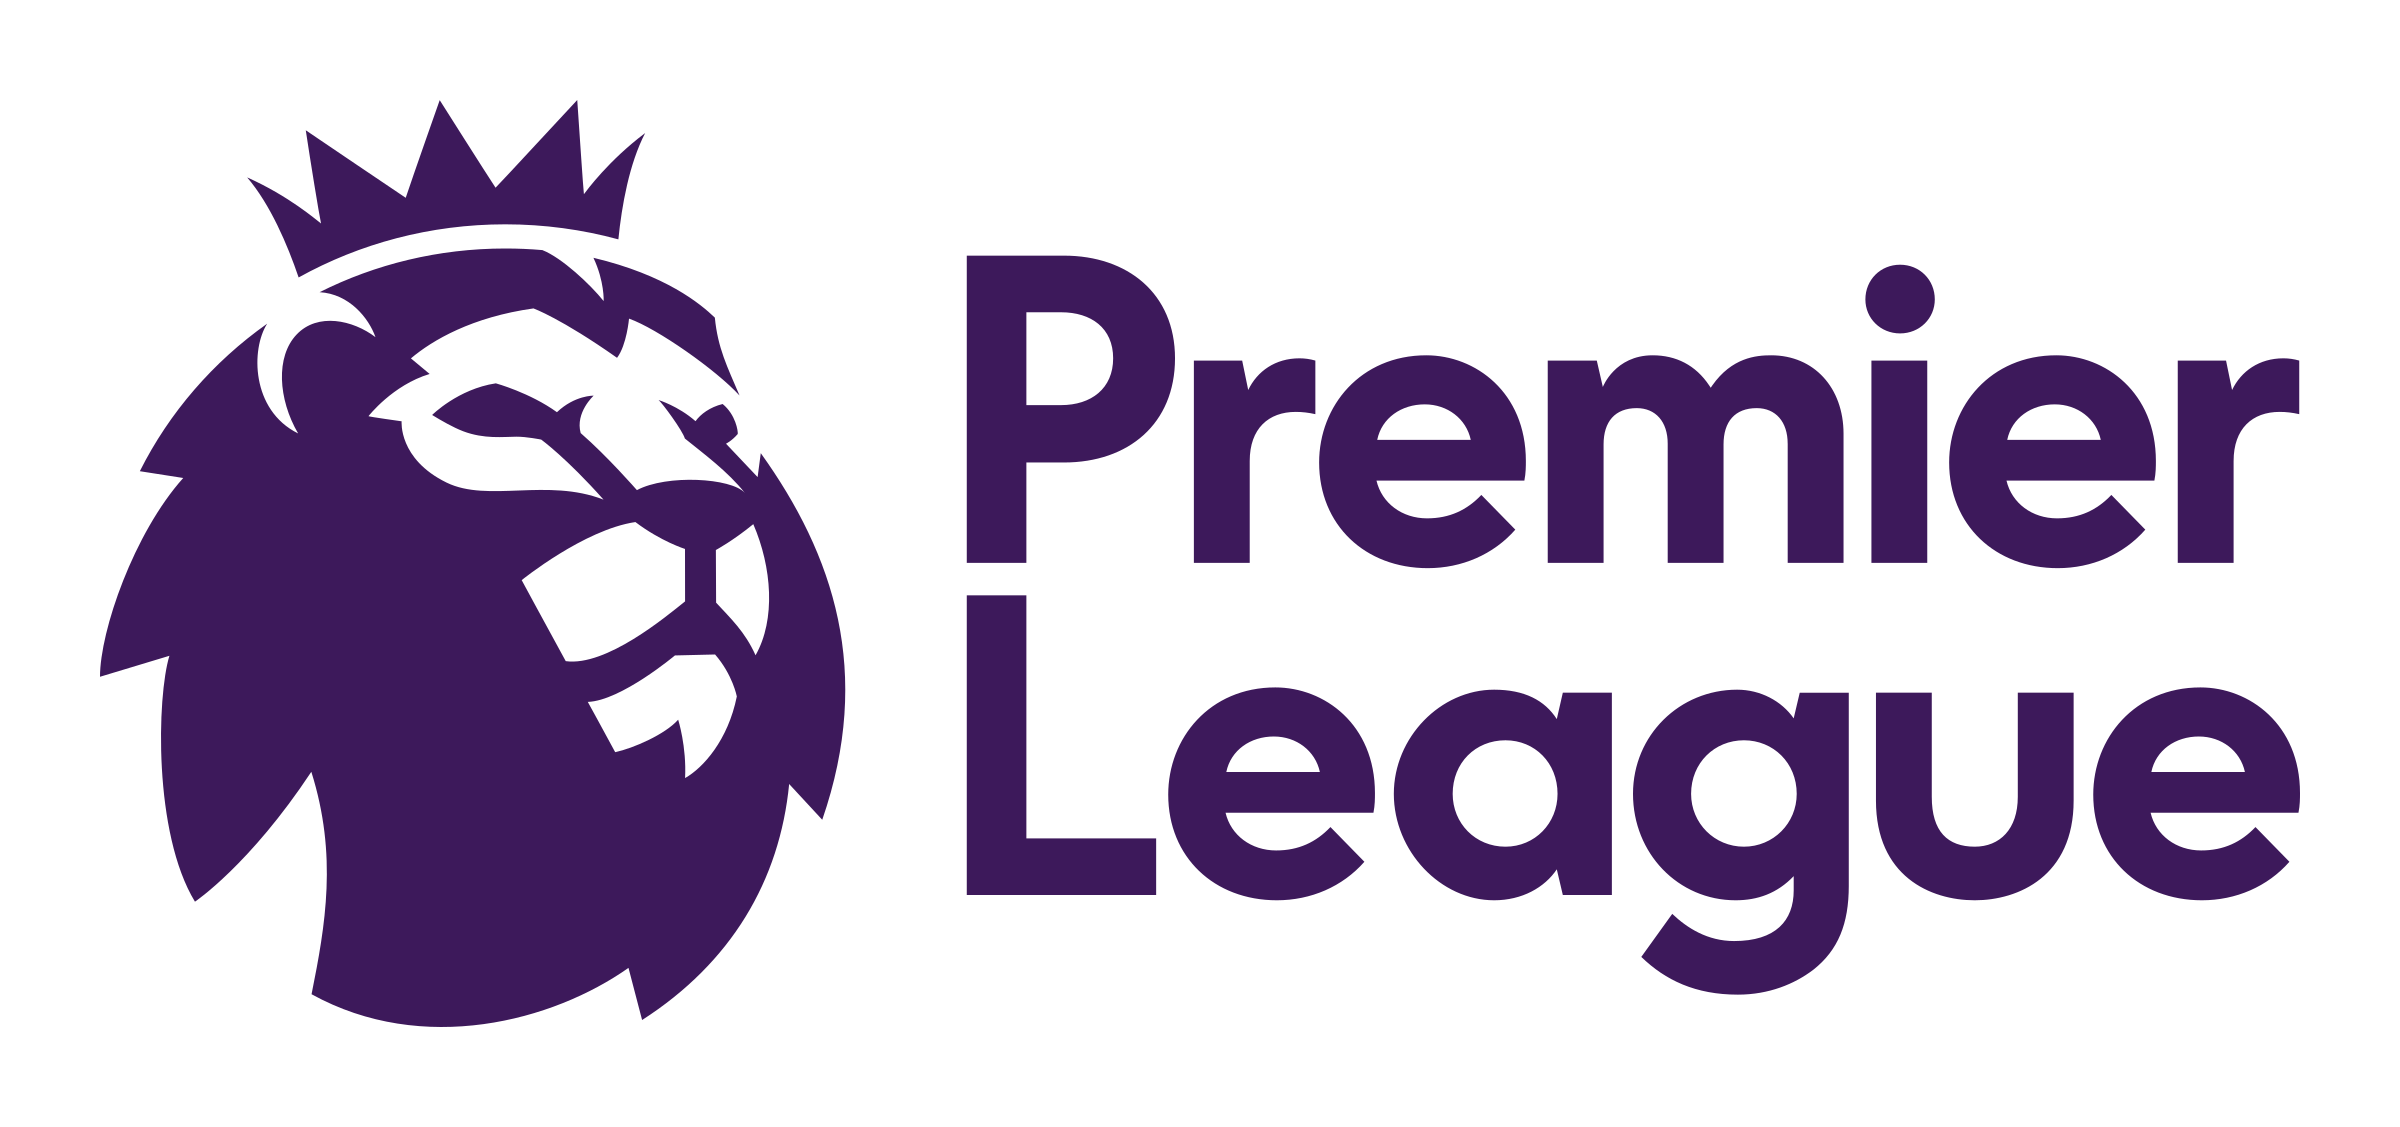

## **- Isha Roy**

# **1. Problem Statement**

The Premier League is the top level of the English football league system. Contested by 20 clubs, it operates promotion and relegation with the English Football League. Seasons run from August to May with each team playing 38 matches (playing all 19 other teams both home and away)

The league held its first season in 1992–93. It was composed of 22 clubs for that season.The number of clubs was reduced to 20, down from 22, in 1995 when four teams were relegated from the league and only two teams promoted.The top flight had only been expanded to 22 teams at the start of the 1991–92 season – the year prior to the formation of the Premier League.

The league changed its name from the FA Premier League to simply the Premier League in 2007.

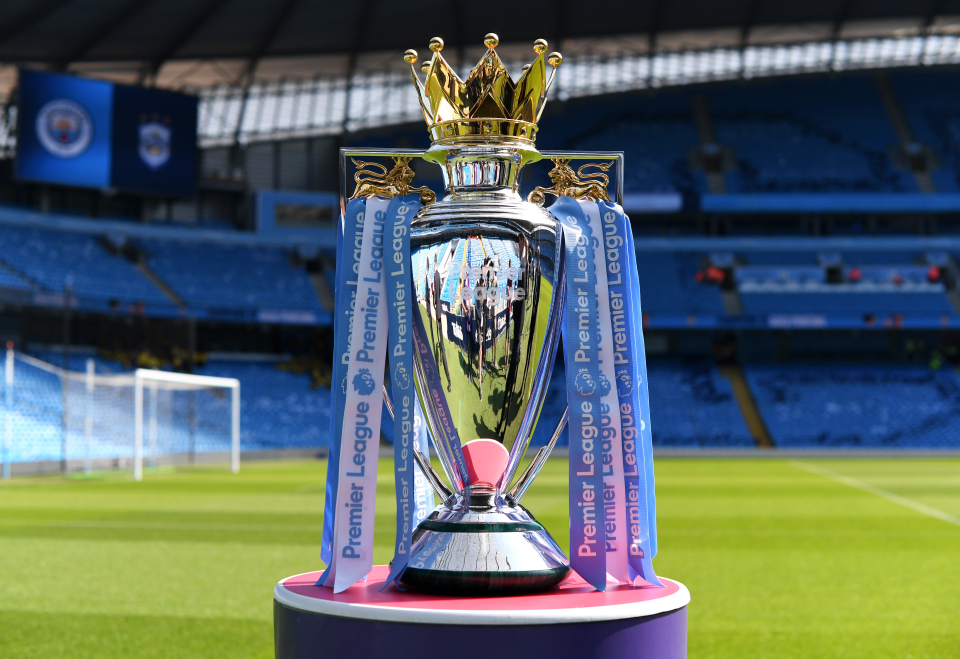

The dataset availabe is used to explore the English Premier League data, so as to understand how it has fared across different seasons and evolved over the years.

**Analysis to be Performed :**

- Season level Analysis for football parameters - Matches, Wins, Losses, Goals(Home and Away), Comebacks.
- Team level analysis for football parameters - Matches, Wins, Losses, Goals(Home and Away), Comebacks.
- Anaylsis of Team per Season - Points Table, Champions, Runner's up, Relegation, League Progress

**Try to Answer :**

- Important Considerations to Sustain in the league (not being relegated)
- How can a Team improve the chances to Win the League ?
- Important factor to win a League - Attack or Defence?

# **2. Setting up Packages/Environment**

In [2]:
!pip install pandas-profiling

You should consider upgrading via the 'c:\users\dell\anaconda3\python.exe -m pip install --upgrade pip' command.


  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27091 sha256=f7ce4b742b78ae475622a69e326d410a0f5d92f72d12a163c75bae571b0679fa
  Stored in directory: c:\users\dell\appdata\local\pip\cache\wheels\23\14\6e\4be5bfeeb027f4939a01764b48edd5996acf574b0913fe5243
  Created wheel for phik: filename=phik-0.11.2-py3-none-any.whl size=1107420 sha256=c8dc7b678f71aca3281156d230b6e7fc4bab4143aba0b042981d342ec65e4f84
  Stored in directory: c:\users\dell\appdata\local\pip\cache\wheels\72\9a\23\097c93fd8341220d92674891b6a9a30f0e389719d9b7291bd2
Successfully built htmlmin phik


In [3]:
!pip install pivottablejs

You should consider upgrading via the 'c:\users\dell\anaconda3\python.exe -m pip install --upgrade pip' command.


In [6]:
import numpy as np
np.set_printoptions(precision=4)

import pandas as pd
pd.set_option('mode.chained_assignment', None)      
pd.set_option('display.max_colwidth', -1)           
pd.options.display.max_columns = 50

import matplotlib.pyplot as plt
plt.style.use('seaborn-whitegrid')                  
%matplotlib inline

import seaborn as sns
sns.set(style='whitegrid', font_scale=1.3, color_codes=True)      

import warnings
warnings.filterwarnings('ignore')

import pandas_profiling                               
from pivottablejs import pivot_ui                   
import webbrowser                                   

import plotly.express as px                         
                     

# Making bokeh specific imports.

from bokeh.plotting import Figure, figure, show, output_notebook,output_file
from bokeh.layouts import column
from bokeh.models import ColumnDataSource, CustomJS, Slider, HoverTool
from bokeh.palettes import Spectral4
from bokeh.io import push_notebook
from bokeh.models import Range1d
output_notebook()


from ipywidgets import interact   

<ipython-input-6-6f10ac47eeb1>:6: FutureWarning: Passing a negative integer is deprecated in version 1.0 and will not be supported in future version. Instead, use None to not limit the column width.
  pd.set_option('display.max_colwidth', -1)


Loading BokehJS ...

# **3. Loading Data**

In [7]:
pl_df = pd.read_csv('EPL_Set.csv')
pl_df.head()

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Season
0,E0,14/08/93,Arsenal,Coventry,0,3,A,NaN,NaN,NaN,1993-94
1,E0,14/08/93,Aston Villa,QPR,4,1,H,NaN,NaN,NaN,1993-94
2,E0,14/08/93,Chelsea,Blackburn,1,2,A,NaN,NaN,NaN,1993-94
3,E0,14/08/93,Liverpool,Sheffield Weds,2,0,H,NaN,NaN,NaN,1993-94
4,E0,14/08/93,Man City,Leeds,1,1,D,NaN,NaN,NaN,1993-94


**Description of Dataset**

- The English Premier League is one of the most popular domestic league in the world.
- This dataset contains 25 years of EPL matches history with goal details and results.

- Div =	League Division
- Date = Match Date
- HomeTeam = Team playing at the Home Ground
- AwayTeam = Team playing at the Away ground
- FTHG = Full-Time Home Team Goals
- FTAG = Full-Time Away Team Goals
- FTR = Full-Time Result (H=Home Win, D=Draw, A=Away Win)
- HTHG = Half-Time Home Team Goals
- HTAG = Half-Time Away Team Goals
- HTR =	Half-Time Result (H=Home Win, D=Draw, A=Away Win)
- Season = Premier Leage Season

In [11]:
pl_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9664 entries, 0 to 9663
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Div       9664 non-null   object 
 1   Date      9664 non-null   object 
 2   HomeTeam  9664 non-null   object 
 3   AwayTeam  9664 non-null   object 
 4   FTHG      9664 non-null   int64  
 5   FTAG      9664 non-null   int64  
 6   FTR       9664 non-null   object 
 7   HTHG      8740 non-null   float64
 8   HTAG      8740 non-null   float64
 9   HTR       8740 non-null   object 
 10  Season    9664 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 830.6+ KB


**Insights from info() regarding our data:**
- Data conisists of a total of 9664 rows and 11 Columns
- 7 columns of object datatype and 4 columns of numeric datatype
- Missing values in 3 columns, namely - HTHG,HTAG and HTR

In [12]:
pl_df.describe(include='all')

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Season
count,9664,9664,9664,9664,9664.000000,9664.000000,9664,8740.000000,8740.000000,8740,9664
unique,1,2572,50,50,NaN,NaN,3,NaN,NaN,3,25
top,E0,17/04/95,Liverpool,Liverpool,NaN,NaN,H,NaN,NaN,D,1994-95
freq,9664,11,479,479,NaN,NaN,4461,NaN,NaN,3679,462
mean,NaN,NaN,NaN,NaN,1.523903,1.121482,NaN,0.685469,0.488444,NaN,NaN
std,NaN,NaN,NaN,NaN,1.301671,1.121667,NaN,0.833581,0.710524,NaN,NaN
min,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,0.000000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,1.000000,0.000000,NaN,0.000000,0.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,1.000000,1.000000,NaN,0.000000,0.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,2.000000,2.000000,NaN,1.000000,1.000000,NaN,NaN


In [15]:
# Saving the output as profiling_before_preprocessing.html
'''
profile = df_merge.profile_report(title='Pandas Profiling before Data Preprocessing')
profile.to_file(output_file="profiling_before_preprocessing.html")
'''

# To output the pandas profiling report on the notebook.

#pl_df.profile_report(title='Pandas Profiling before Data Preprocessing', style={'full_width':True})


profile = pandas_profiling.ProfileReport(pl_df)
profile.to_file(output_file="profiling_before_preprocessing.html")

**Observations :**
 - No. Of Variables            :   11
 - No. Of Records/Observations : 9664
 - Missing Cells               : 2772 (2.6%)

**Types Of Variables :**
 - Categorical : 7
 - Numerical   : 4


- Div column has only 1 value E0 and can be dropped
- Date has high cardinality (expected)
- Date field has different formats across like 'dd/mm/yy' or 'dd/mm/yyyy'
- HTHG , HTAG and HTR have 9.6% missing values (924 values in each)
- FTHG and FTAG has some values as 0s (expected)

# **4. Data Preprocessing**


Fixing the data for any issues before performing EDA

In [16]:
pl_df.head()

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Season
0,E0,14/08/93,Arsenal,Coventry,0,3,A,NaN,NaN,NaN,1993-94
1,E0,14/08/93,Aston Villa,QPR,4,1,H,NaN,NaN,NaN,1993-94
2,E0,14/08/93,Chelsea,Blackburn,1,2,A,NaN,NaN,NaN,1993-94
3,E0,14/08/93,Liverpool,Sheffield Weds,2,0,H,NaN,NaN,NaN,1993-94
4,E0,14/08/93,Man City,Leeds,1,1,D,NaN,NaN,NaN,1993-94


Dropping Div column as its constant throughout.

In [17]:
pl_df.drop(['Div'],axis=1,inplace=True)

In [18]:
pl_df.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Season
0,14/08/93,Arsenal,Coventry,0,3,A,NaN,NaN,NaN,1993-94
1,14/08/93,Aston Villa,QPR,4,1,H,NaN,NaN,NaN,1993-94
2,14/08/93,Chelsea,Blackburn,1,2,A,NaN,NaN,NaN,1993-94
3,14/08/93,Liverpool,Sheffield Weds,2,0,H,NaN,NaN,NaN,1993-94
4,14/08/93,Man City,Leeds,1,1,D,NaN,NaN,NaN,1993-94


As noted in Preprofiling, the DATE column is object type and has different formats. Using datetime to have all the values in common datetime format and dtype chenged to datetime for any further processes.

In [19]:
pl_df['New_Date'] = pd.to_datetime(pl_df.Date , format ='%d/%m/%Y',errors='coerce')
fil = pl_df.New_Date.isnull()
pl_df.loc[fil,'New_Date'] = pd.to_datetime(pl_df[fil]['Date'],errors='coerce')

In [20]:
pl_df.info()
pl_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9664 entries, 0 to 9663
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      9664 non-null   object        
 1   HomeTeam  9664 non-null   object        
 2   AwayTeam  9664 non-null   object        
 3   FTHG      9664 non-null   int64         
 4   FTAG      9664 non-null   int64         
 5   FTR       9664 non-null   object        
 6   HTHG      8740 non-null   float64       
 7   HTAG      8740 non-null   float64       
 8   HTR       8740 non-null   object        
 9   Season    9664 non-null   object        
 10  New_Date  9664 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(2), object(6)
memory usage: 830.6+ KB


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Season,New_Date
0,14/08/93,Arsenal,Coventry,0,3,A,NaN,NaN,NaN,1993-94,1993-08-14
1,14/08/93,Aston Villa,QPR,4,1,H,NaN,NaN,NaN,1993-94,1993-08-14
2,14/08/93,Chelsea,Blackburn,1,2,A,NaN,NaN,NaN,1993-94,1993-08-14
3,14/08/93,Liverpool,Sheffield Weds,2,0,H,NaN,NaN,NaN,1993-94,1993-08-14
4,14/08/93,Man City,Leeds,1,1,D,NaN,NaN,NaN,1993-94,1993-08-14


In [21]:
print(pl_df[pl_df['HTHG'].isnull()]['Season'].value_counts())
print(pl_df[pl_df['HTAG'].isnull()]['Season'].value_counts())
print(pl_df[pl_df['HTR'].isnull()]['Season'].value_counts())
print(pl_df['Season'].value_counts())

1994-95    462
1993-94    462
Name: Season, dtype: int64
1994-95    462
1993-94    462
Name: Season, dtype: int64
1994-95    462
1993-94    462
Name: Season, dtype: int64
1994-95    462
1993-94    462
2008-09    380
2000-01    380
2004-05    380
2017-18    380
1996-97    380
2013-14    380
2009-10    380
2011-12    380
2001-02    380
2014-15    380
2005-06    380
2012-13    380
1995-96    380
2002-03    380
2016-17    380
2006-07    380
1997-98    380
1999-00    380
2015-16    380
1998-99    380
2003-04    380
2010-11    380
2007-08    380
Name: Season, dtype: int64


This shows that all values for HTHG , HTAG and HTR in the seasons 1993-94 and 1994-95 are Null. We replace the goal values as 0 and half time result as D (draw) for simplicity in below code and also as the rules for no. of teams and relegated teams changed post this season, most of our analysis will be on latest format of the tournament.

In [22]:
pl_df[['HTHG','HTAG']] = pl_df[['HTHG','HTAG']].fillna(value=0).astype(int)
pl_df['HTR'] = pl_df['HTR'].fillna(value='D')
pl_df.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Season,New_Date
0,14/08/93,Arsenal,Coventry,0,3,A,0,0,D,1993-94,1993-08-14
1,14/08/93,Aston Villa,QPR,4,1,H,0,0,D,1993-94,1993-08-14
2,14/08/93,Chelsea,Blackburn,1,2,A,0,0,D,1993-94,1993-08-14
3,14/08/93,Liverpool,Sheffield Weds,2,0,H,0,0,D,1993-94,1993-08-14
4,14/08/93,Man City,Leeds,1,1,D,0,0,D,1993-94,1993-08-14


In [23]:
profile = pandas_profiling.ProfileReport(pl_df)
profile.to_file(output_file="profiling_after_preprocessing.html")

Profiling Results after data preprocessing -
Observations :

     - No. Of Variables            :   10
     - No. Of Records/Observations : 9664
     - Missing Cells               :    0
Types Of Variables :

     - Categorical : 5
     - Numerical   : 4
     - Date        : 1

Div column was constant and thus dropped.
Date field made as datetime dtype and thus formatting issue fixed.
Missing values filled for HTHG, HTAG and HTR columns.

# **5. Exploratory Data Analysis**

**5.1 Season Level Analysis**

Analysis of no.of matches, teams, total goals, goals per match, distribution of goals (home and away)and comebacks at the SEASON Level (Season Wise)

*5.1.1 Total Games Per Season*

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24]),
 [Text(0, 0, '1993-94'),
  Text(1, 0, '1994-95'),
  Text(2, 0, '1995-96'),
  Text(3, 0, '1996-97'),
  Text(4, 0, '1997-98'),
  Text(5, 0, '1998-99'),
  Text(6, 0, '1999-00'),
  Text(7, 0, '2000-01'),
  Text(8, 0, '2001-02'),
  Text(9, 0, '2002-03'),
  Text(10, 0, '2003-04'),
  Text(11, 0, '2004-05'),
  Text(12, 0, '2005-06'),
  Text(13, 0, '2006-07'),
  Text(14, 0, '2007-08'),
  Text(15, 0, '2008-09'),
  Text(16, 0, '2009-10'),
  Text(17, 0, '2010-11'),
  Text(18, 0, '2011-12'),
  Text(19, 0, '2012-13'),
  Text(20, 0, '2013-14'),
  Text(21, 0, '2014-15'),
  Text(22, 0, '2015-16'),
  Text(23, 0, '2016-17'),
  Text(24, 0, '2017-18')])

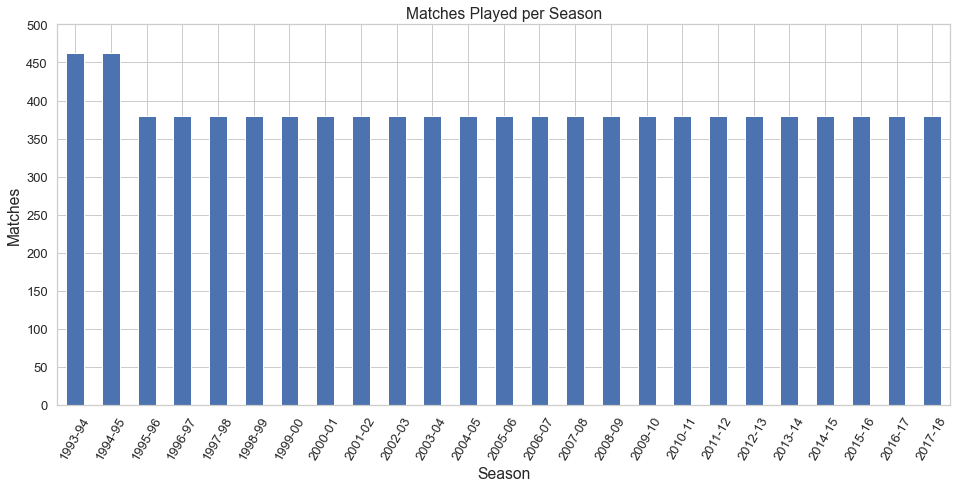

In [25]:
pl_df.groupby('Season')['Season'].count().plot(kind='bar',fontsize=13,figsize=(16,7),yticks=np.arange(0,501,50))

plt.title("Matches Played per Season")
plt.xlabel("Season")
plt.ylabel("Matches")
plt.xticks(rotation=60)

**Observations:**
No. of games in first 2 seasons 1993-94 and 1994-95 are higher than all other seasons. This is beacuase the format of the tournament was changed after 1994-95 Season.

*5.1.2 No. Of Teams per Season*


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24]),
 [Text(0, 0, '1993-94'),
  Text(1, 0, '1994-95'),
  Text(2, 0, '1995-96'),
  Text(3, 0, '1996-97'),
  Text(4, 0, '1997-98'),
  Text(5, 0, '1998-99'),
  Text(6, 0, '1999-00'),
  Text(7, 0, '2000-01'),
  Text(8, 0, '2001-02'),
  Text(9, 0, '2002-03'),
  Text(10, 0, '2003-04'),
  Text(11, 0, '2004-05'),
  Text(12, 0, '2005-06'),
  Text(13, 0, '2006-07'),
  Text(14, 0, '2007-08'),
  Text(15, 0, '2008-09'),
  Text(16, 0, '2009-10'),
  Text(17, 0, '2010-11'),
  Text(18, 0, '2011-12'),
  Text(19, 0, '2012-13'),
  Text(20, 0, '2013-14'),
  Text(21, 0, '2014-15'),
  Text(22, 0, '2015-16'),
  Text(23, 0, '2016-17'),
  Text(24, 0, '2017-18')])

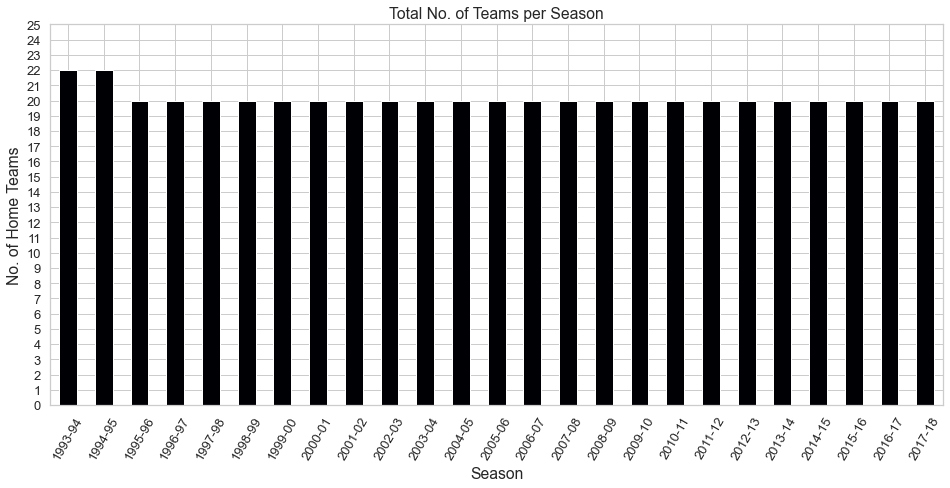

In [26]:
pl_df.groupby('Season')['HomeTeam'].nunique().plot(kind='bar',colormap='magma',fontsize=13,figsize=(16,7),yticks=np.arange(0, 26))
plt.ylabel('No. of Home Teams')
plt.title("Total No. of Teams per Season")
plt.xticks(rotation=60)

**Observations:**
- The first 2 seasons has 22 teams while rest of the seasons had 20 teams particiapting.
- This observation concludes why the no. of matches were higher in the first 2 seasons as seen in #1.

*5.1.3 Goals per Season*

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24]),
 [Text(0, 0, '1993-94'),
  Text(1, 0, '1994-95'),
  Text(2, 0, '1995-96'),
  Text(3, 0, '1996-97'),
  Text(4, 0, '1997-98'),
  Text(5, 0, '1998-99'),
  Text(6, 0, '1999-00'),
  Text(7, 0, '2000-01'),
  Text(8, 0, '2001-02'),
  Text(9, 0, '2002-03'),
  Text(10, 0, '2003-04'),
  Text(11, 0, '2004-05'),
  Text(12, 0, '2005-06'),
  Text(13, 0, '2006-07'),
  Text(14, 0, '2007-08'),
  Text(15, 0, '2008-09'),
  Text(16, 0, '2009-10'),
  Text(17, 0, '2010-11'),
  Text(18, 0, '2011-12'),
  Text(19, 0, '2012-13'),
  Text(20, 0, '2013-14'),
  Text(21, 0, '2014-15'),
  Text(22, 0, '2015-16'),
  Text(23, 0, '2016-17'),
  Text(24, 0, '2017-18')])

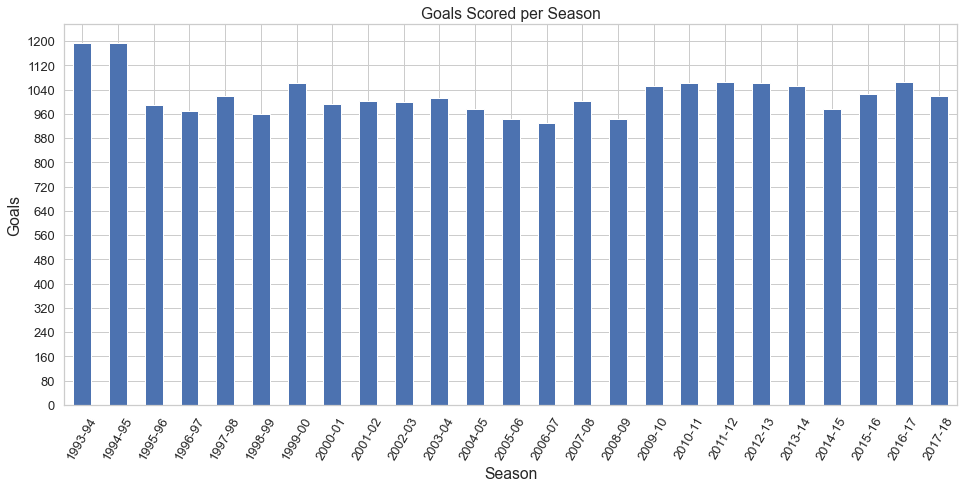

In [27]:
pl_df['Total_Match_Goals'] = pl_df['FTHG'] + pl_df['FTAG']

pl_df.groupby('Season')['Total_Match_Goals'].sum().plot(kind='bar',fontsize=13,figsize=(16,7),yticks=np.arange(0,1201,80)) 

plt.title("Goals Scored per Season")
plt.xlabel("Season")
plt.ylabel("Goals")
plt.xticks(rotation=60)

**Observations:**
After the no. of teams were reduced post 1994-95, most goals were score in the season 2011-12 and least in 2006-07. There is no set pattern observed in the game.

*5.1.3.1 Goals per Game in a Season*

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24]),
 [Text(0, 0, '1993-94'),
  Text(1, 0, '1994-95'),
  Text(2, 0, '1995-96'),
  Text(3, 0, '1996-97'),
  Text(4, 0, '1997-98'),
  Text(5, 0, '1998-99'),
  Text(6, 0, '1999-00'),
  Text(7, 0, '2000-01'),
  Text(8, 0, '2001-02'),
  Text(9, 0, '2002-03'),
  Text(10, 0, '2003-04'),
  Text(11, 0, '2004-05'),
  Text(12, 0, '2005-06'),
  Text(13, 0, '2006-07'),
  Text(14, 0, '2007-08'),
  Text(15, 0, '2008-09'),
  Text(16, 0, '2009-10'),
  Text(17, 0, '2010-11'),
  Text(18, 0, '2011-12'),
  Text(19, 0, '2012-13'),
  Text(20, 0, '2013-14'),
  Text(21, 0, '2014-15'),
  Text(22, 0, '2015-16'),
  Text(23, 0, '2016-17'),
  Text(24, 0, '2017-18')])

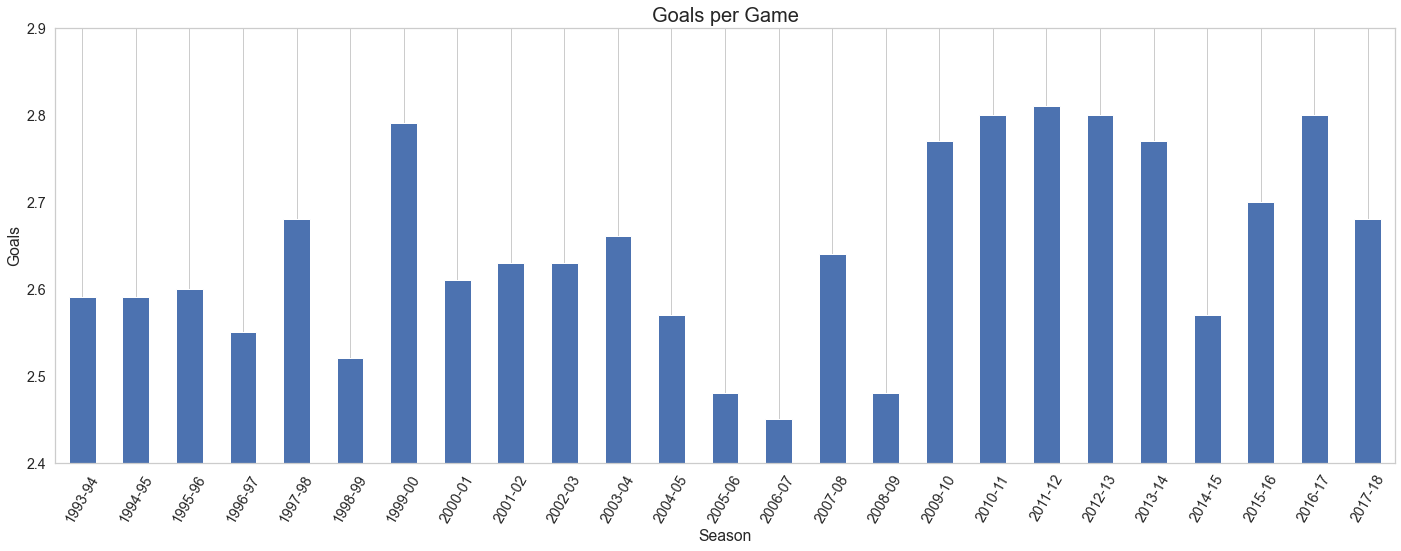

In [29]:
gpm = round(pl_df.groupby('Season')['Total_Match_Goals'].sum()/pl_df.groupby('Season')['Season'].count(),2)
gpm.plot(kind='bar',width=0.5,figsize=(24,8))

plt.grid(axis='y')
plt.ylim(2.4,2.9)  ##min value = 2.45 as seen in data [gpm.min()]
plt.ylabel('Goals')
plt.title("Goals per Game",fontsize=20)
plt.xticks(rotation=60)

**Observations** 
Even though the total goals in first 2 seasons is higher (due to more teams), the Goals/Game is low. This hints that overall Season Quality in terms of goals was low and possible reason to reduce the teams in the following seasons.
Best and worst Goals per Game ratio is in accordance with the Total Goals scored i.e. season 2011-12 and 2006-07 respectively.

*5.1.3.2 Distribution of Home and Away Team Goals per Season*

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24]),
 [Text(0, 0, '1993-94'),
  Text(1, 0, '1994-95'),
  Text(2, 0, '1995-96'),
  Text(3, 0, '1996-97'),
  Text(4, 0, '1997-98'),
  Text(5, 0, '1998-99'),
  Text(6, 0, '1999-00'),
  Text(7, 0, '2000-01'),
  Text(8, 0, '2001-02'),
  Text(9, 0, '2002-03'),
  Text(10, 0, '2003-04'),
  Text(11, 0, '2004-05'),
  Text(12, 0, '2005-06'),
  Text(13, 0, '2006-07'),
  Text(14, 0, '2007-08'),
  Text(15, 0, '2008-09'),
  Text(16, 0, '2009-10'),
  Text(17, 0, '2010-11'),
  Text(18, 0, '2011-12'),
  Text(19, 0, '2012-13'),
  Text(20, 0, '2013-14'),
  Text(21, 0, '2014-15'),
  Text(22, 0, '2015-16'),
  Text(23, 0, '2016-17'),
  Text(24, 0, '2017-18')])

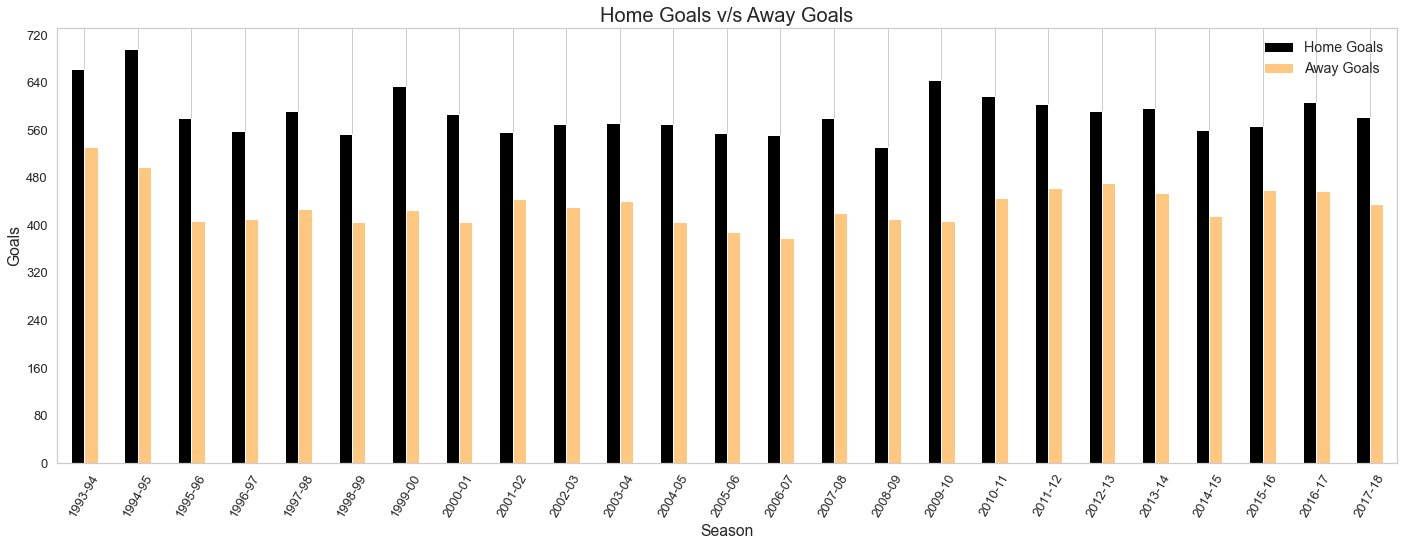

In [32]:
pl_df.groupby('Season')[['FTHG','FTAG']].sum().plot(kind='bar',fontsize=13,figsize=(24,8),yticks=np.arange(0,721,80),colormap='copper')
plt.grid(axis='y')
plt.ylabel('Goals')
plt.legend(['Home Goals','Away Goals'])
plt.title("Home Goals v/s Away Goals",fontsize=20)
plt.xticks(rotation=60)

**Observations :**
All seasons have more Home Goals than Away goals hinting towards possible Home Ground Advantage for goal scoring.

*5.1.3.3 Ratio of Home Goals to Away Goals per Season*

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24]),
 [Text(0, 0, '1993-94'),
  Text(1, 0, '1994-95'),
  Text(2, 0, '1995-96'),
  Text(3, 0, '1996-97'),
  Text(4, 0, '1997-98'),
  Text(5, 0, '1998-99'),
  Text(6, 0, '1999-00'),
  Text(7, 0, '2000-01'),
  Text(8, 0, '2001-02'),
  Text(9, 0, '2002-03'),
  Text(10, 0, '2003-04'),
  Text(11, 0, '2004-05'),
  Text(12, 0, '2005-06'),
  Text(13, 0, '2006-07'),
  Text(14, 0, '2007-08'),
  Text(15, 0, '2008-09'),
  Text(16, 0, '2009-10'),
  Text(17, 0, '2010-11'),
  Text(18, 0, '2011-12'),
  Text(19, 0, '2012-13'),
  Text(20, 0, '2013-14'),
  Text(21, 0, '2014-15'),
  Text(22, 0, '2015-16'),
  Text(23, 0, '2016-17'),
  Text(24, 0, '2017-18')])

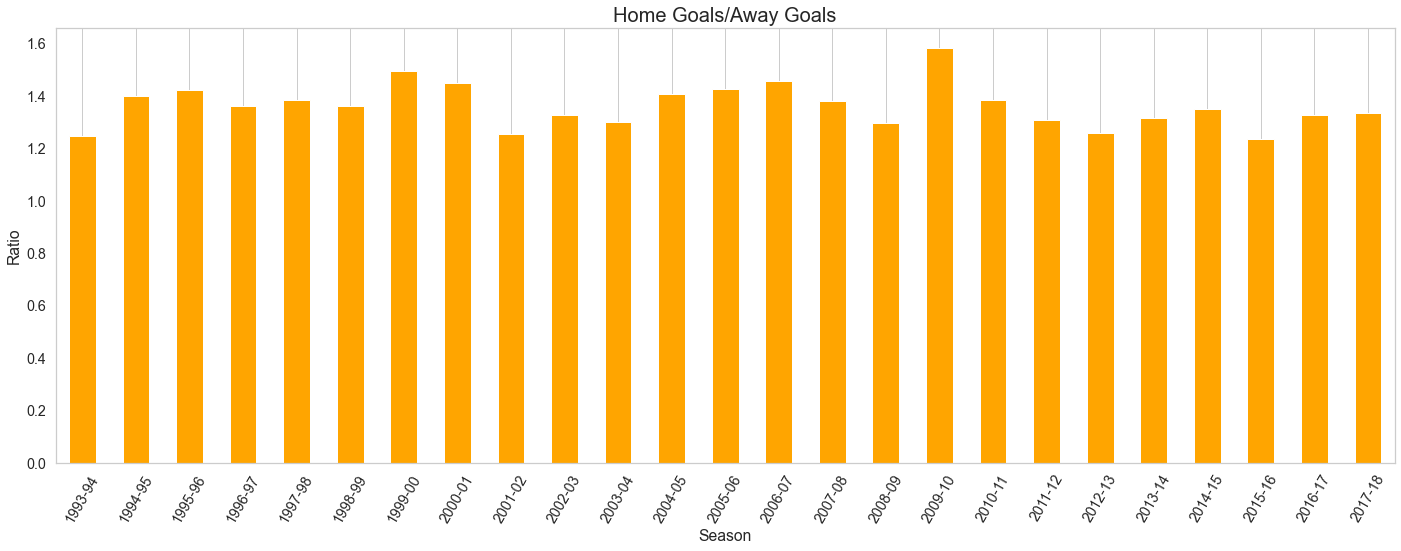

In [33]:
round((pl_df.groupby('Season')['FTHG'].sum()/pl_df.groupby('Season')['FTAG'].sum()),3).plot(kind='bar',figsize=(24,8),color='orange')
plt.grid(axis='y')
plt.ylabel("Ratio")
plt.title("Home Goals/Away Goals",fontsize= 20)
plt.xticks(rotation=60)

**Observations :**
- Best Home/Away Goal ratio is for Season 2009-10
- Worst Home/Away Goal ratio is for Season 2015-16 (more even spread of home and away goals)

*5.1.4 Comebacks per Season*


Comebacks are defined as to when a team losing at halftime goes on to win the match at full time.

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24]),
 [Text(0, 0, '1993-94'),
  Text(1, 0, '1994-95'),
  Text(2, 0, '1995-96'),
  Text(3, 0, '1996-97'),
  Text(4, 0, '1997-98'),
  Text(5, 0, '1998-99'),
  Text(6, 0, '1999-00'),
  Text(7, 0, '2000-01'),
  Text(8, 0, '2001-02'),
  Text(9, 0, '2002-03'),
  Text(10, 0, '2003-04'),
  Text(11, 0, '2004-05'),
  Text(12, 0, '2005-06'),
  Text(13, 0, '2006-07'),
  Text(14, 0, '2007-08'),
  Text(15, 0, '2008-09'),
  Text(16, 0, '2009-10'),
  Text(17, 0, '2010-11'),
  Text(18, 0, '2011-12'),
  Text(19, 0, '2012-13'),
  Text(20, 0, '2013-14'),
  Text(21, 0, '2014-15'),
  Text(22, 0, '2015-16'),
  Text(23, 0, '2016-17'),
  Text(24, 0, '2017-18')])

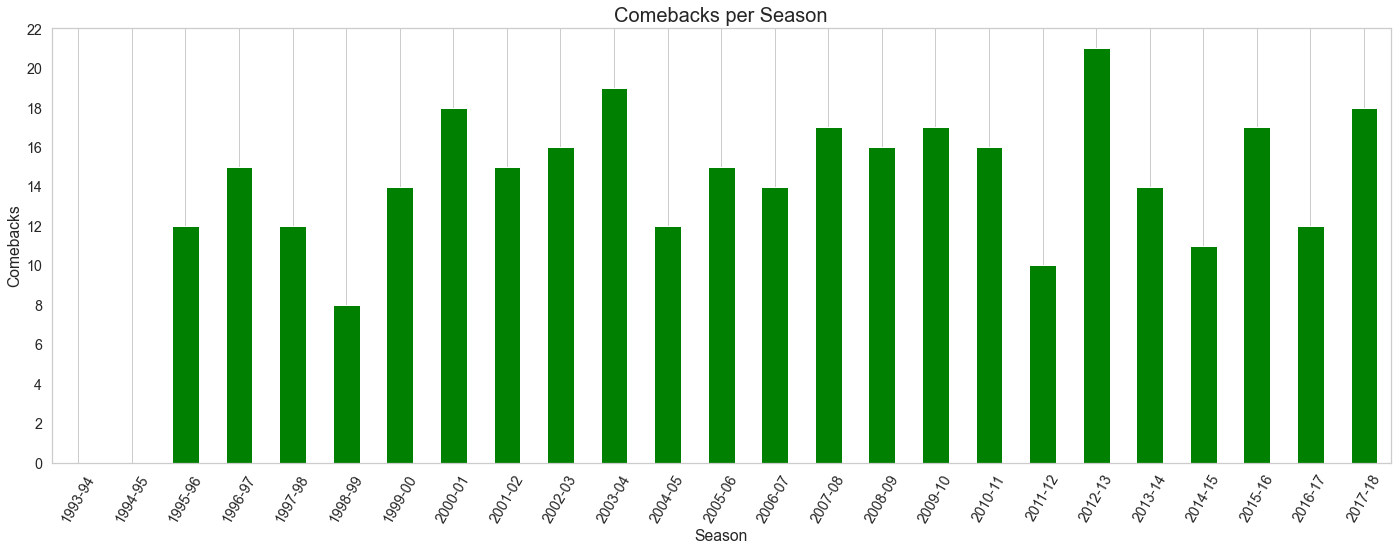

In [35]:
pl_df['Comeback']=np.where((pl_df['FTR']!=pl_df['HTR'])&(pl_df['FTR']!='D') & (pl_df['HTR']!='D'),1,0)

pl_df.groupby('Season')['Comeback'].sum().plot(kind='bar',figsize=(24,8),color='green',yticks=np.arange(0,23,2))
plt.grid(axis='y')
plt.title("Comebacks per Season",fontsize=20)
plt.ylabel('Comebacks')
plt.xticks(rotation=60)

**Observations:**
No data in initial 2 seasons as the data was manipulated to be all Draws at Half Time (missing data)
Best Season in terms of comebacks was season 2012-13 (More games where the haltime result was changed) and the worst season was 1998-99

--------